<a href="https://colab.research.google.com/github/romialcoba/challenge_telecomx_latam_parte2/blob/main/telecomx_latam_parte2_ra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto TelecomXLATAM PARTE 2

Telecom X - Análisis de Evasión de Clientes
Has sido contratado como asistente de análisis de datos en Telecom X y formarás parte del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

Tu desafío será recopilar, procesar y analizar los datos, utilizando Python y sus principales bibliotecas para extraer información valiosa. A partir de tu análisis, el equipo de Data Science podrá avanzar en modelos predictivos y desarrollar estrategias para reducir la evasión.

## 1-Extracción del Archivo Tratado

In [8]:
import pandas as pd

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:

df = pd.read_csv('/content/drive/MyDrive/telecom_churn_cleaned.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   object 
 5   customer_Dependents        7043 non-null   object 
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   object 
 8   phone_MultipleLines        7043 non-null   object 
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   object 
 11  internet_OnlineBackup      7043 non-null   object 
 12  internet_DeviceProtection  7043 non-null   object 
 13  internet_TechSupport       7043 non-null   objec

## 2- Eliminación de Columnas Irrelevantes

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [11]:
df = df.drop('customerID', axis=1)
display(df.head())

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


##3-Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder

### Identificar columnas categóricas

Se identifica todas las columnas en el DataFrame que son de tipo 'object' (categóricas) y que necesitan ser codificadas.


In [12]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns identified: {categorical_cols}")

Categorical columns identified: ['Churn', 'customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']


In [13]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
display(df_encoded.head())

,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total,Churn_No,Churn_Yes,customer_gender_Female,customer_gender_Male,customer_Partner_No,customer_Partner_Yes,...,internet_StreamingMovies_Yes,account_Contract_Month-to-month,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_No,account_PaperlessBilling_Yes,account_PaymentMethod_Bank transfer (automatic),account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,True,False,True,False,False,True,...,False,False,True,False,False,True,False,False,False,True
1,0,9,59.9,542.40,True,False,False,True,True,False,...,True,True,False,False,True,False,False,False,False,True
2,0,4,73.9,280.85,False,True,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
3,1,13,98.0,1237.85,False,True,False,True,False,True,...,True,True,False,False,False,True,False,False,True,False
4,1,3,83.9,267.40,False,True,True,False,False,True,...,False,True,False,False,False,True,False,False,False,True


##4-Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()

In [14]:
# Calcular la proporción de Churn
churn_proportion = df_encoded['Churn_Yes'].value_counts(normalize=True) * 100

print("Proporción de cancelación (Churn):")
print(churn_proportion)

# Evaluar el desbalance
if churn_proportion[True] > 30:
    print("\nAdvertencia: Hay un desbalance significativo en la clase 'Churn_Yes'.")
elif churn_proportion[True] < 10:
    print("\nAdvertencia: La clase 'Churn_Yes' está muy desbalanceada.")
else:
    print("\nLa proporción de clases parece razonable.")

Proporción de cancelación (Churn):
Churn_Yes
False    73.463013
True     26.536987
Name: proportion, dtype: float64

La proporción de clases parece razonable.


##5-Normalización o Estandarización (si es necesario)

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

## Identificar columnas numéricas

Se identifica todas las columnas numéricas en el DataFrame `df_encoded` que serían candidatas para normalización o estandarización. Esto incluirá las columnas `int64`, `float64` y las nuevas columnas binarias creadas por el One-Hot Encoding.


In [15]:
numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64', 'uint8']).columns.tolist()
print(f"Numerical columns identified: {numeric_cols}")

Numerical columns identified: ['customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']


### Importancia de la Normalización/Estandarización

La normalización y estandarización son técnicas de preprocesamiento esenciales en el machine learning, especialmente cuando se trabaja con características numéricas que tienen diferentes escalas o rangos.

*   **Modelos basados en distancia (KNN, SVM, Regresión Logística, Redes Neuronales)**:
    Estos modelos calculan distancias entre puntos de datos o dependen de funciones de pérdida que son sensibles a la magnitud de las características. Si una característica tiene un rango mucho mayor que otra, dominará el cálculo de la distancia, lo que puede llevar a que el modelo le asigne una importancia indebida. La normalización (escalado a un rango específico, por ejemplo, [0, 1]) o la estandarización (escalado para tener media cero y varianza unitaria) asegura que todas las características contribuyan de manera equitativa al modelo.

*   **Modelos basados en árboles (Decision Tree, Random Forest, XGBoost)**:
    Estos modelos funcionan dividiendo el espacio de características basado en umbrales y no calculan distancias entre puntos. Por lo tanto, no son sensibles a la escala de las características. La normalización o estandarización generalmente no es necesaria para mejorar el rendimiento de los modelos basados en árboles, aunque puede ser útil para la interpretabilidad o para algoritmos que combinan conceptos de distancia (como algunos métodos de regularización o en el contexto de ensambles con modelos sensibles a la escala).

### Recomendación

Dado que se menciona que el equipo de Data Science avanzará en "modelos predictivos", es muy probable que se consideren modelos como la Regresión Logística, SVM o Redes Neuronales, los cuales se benefician significativamente de la normalización o estandarización. Incluso si se usan modelos basados en árboles, escalar los datos no suele perjudicarlos y puede ser beneficioso si se planea experimentar con una variedad de algoritmos.

Por lo tanto, se recomienda proceder con la normalización o estandarización de las columnas numéricas identificadas (`customer_SeniorCitizen`, `customer_tenure`, `account_Charges.Monthly`, `account_Charges.Total`), así como las columnas binarias que surgieron del one-hot encoding, si estas últimas se van a tratar de manera similar a otras características numéricas en ciertos contextos. Para este caso, las columnas binarias creadas por el One-Hot Encoding no requieren normalización, ya que ya están en una escala consistente (0 o 1). La normalización/estandarización se aplicaría a las columnas `customer_SeniorCitizen`, `customer_tenure`, `account_Charges.Monthly` y `account_Charges.Total`.

##6-Análisis de Correlación

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

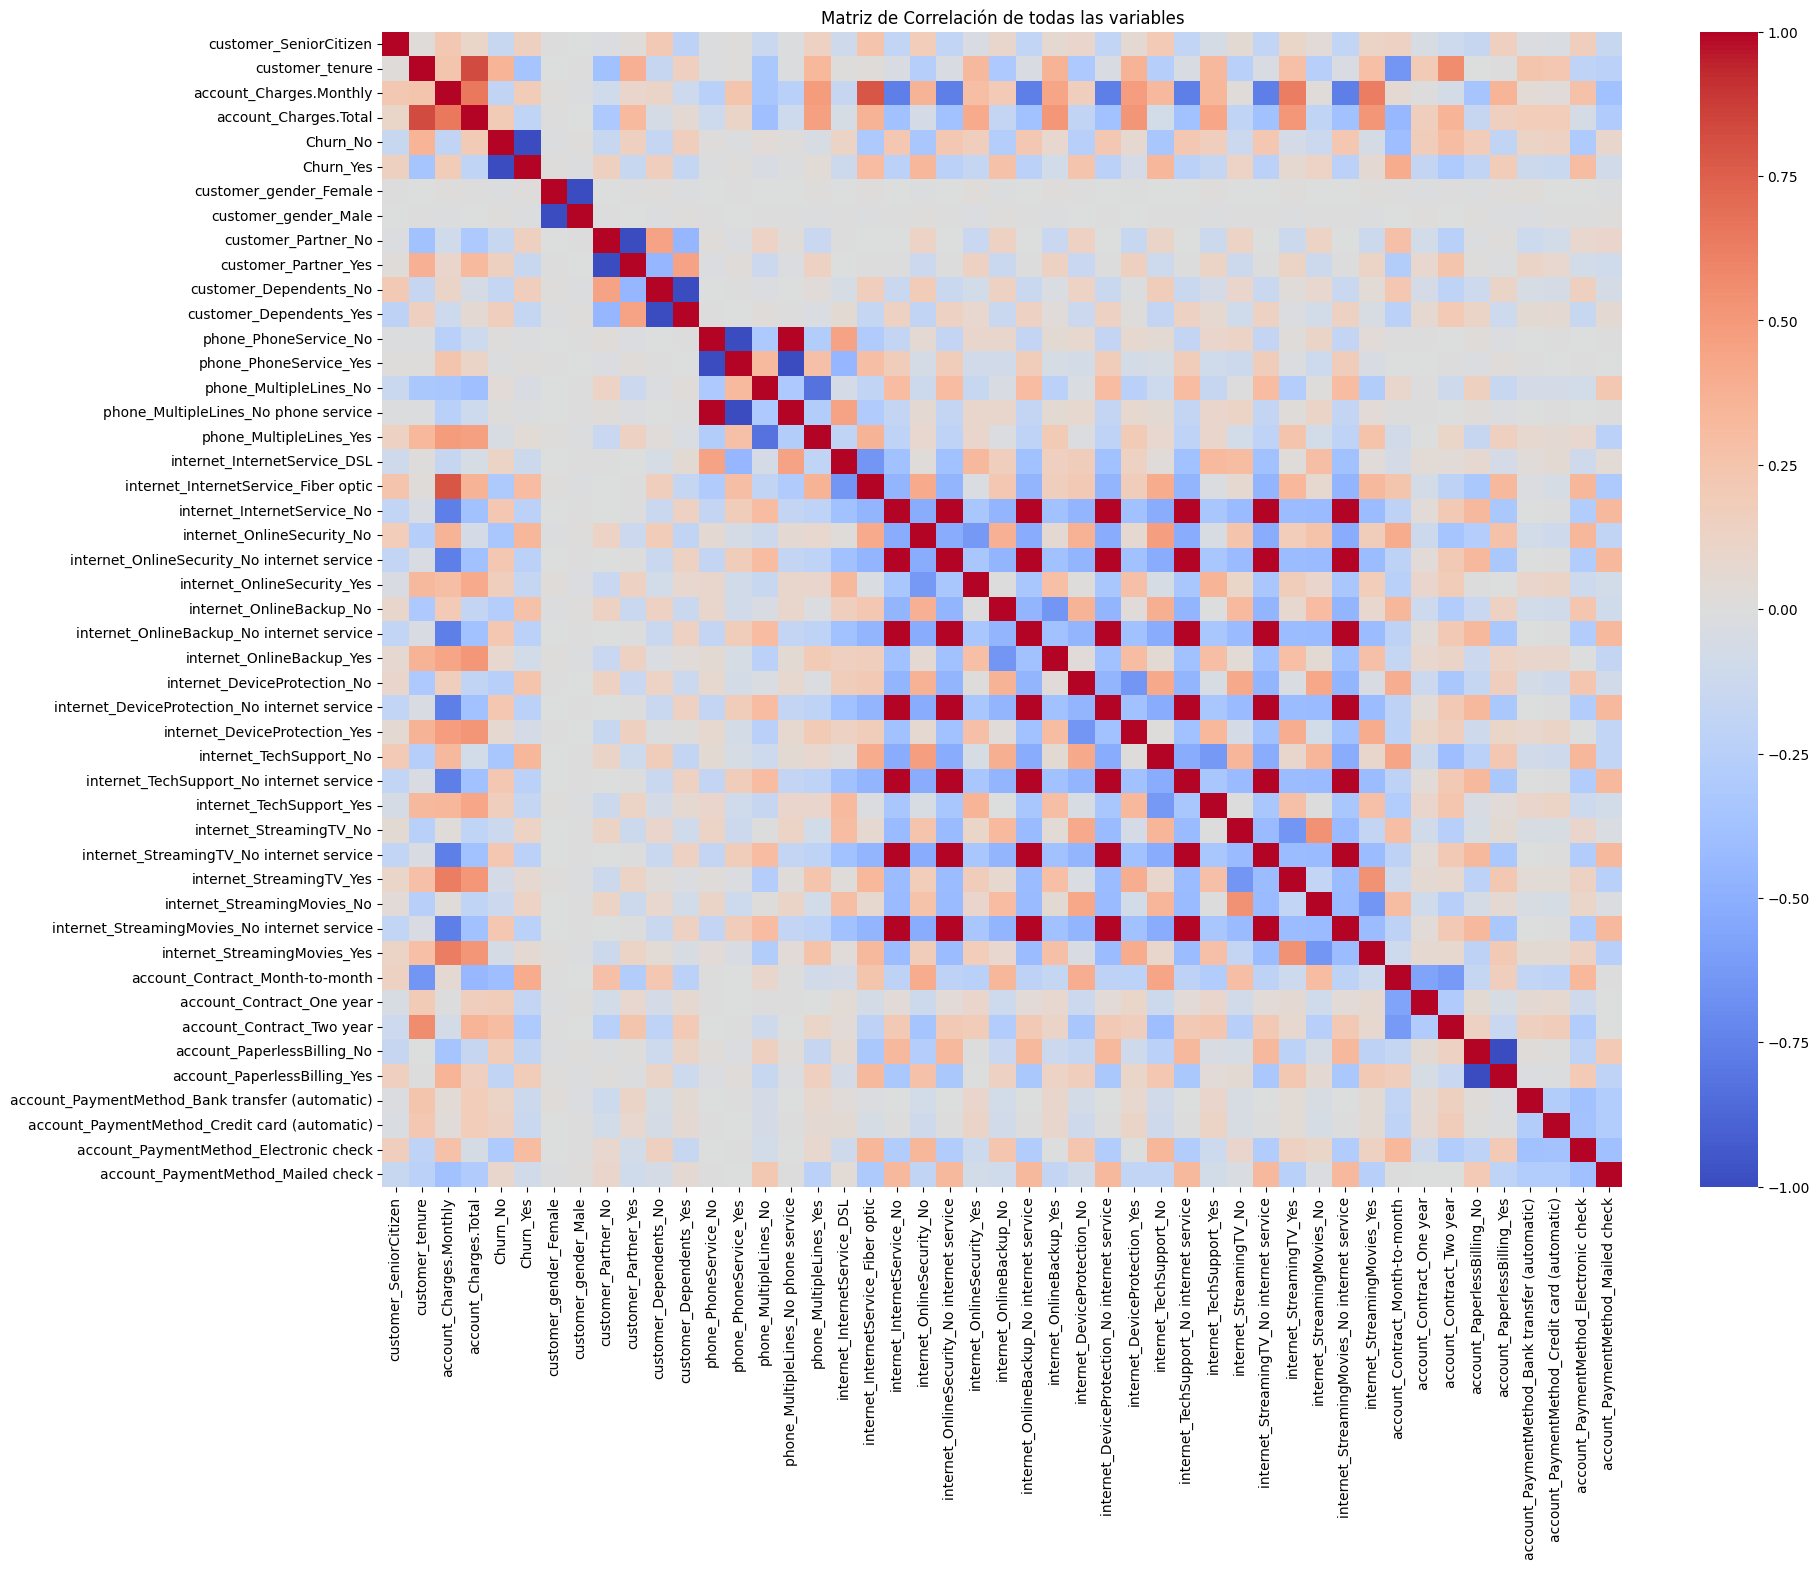


Correlación con 'Churn_Yes':
Churn_Yes                                          1.000000
account_Contract_Month-to-month                    0.405103
internet_OnlineSecurity_No                         0.342637
internet_TechSupport_No                            0.337281
internet_InternetService_Fiber optic               0.308020
account_PaymentMethod_Electronic check             0.301919
internet_OnlineBackup_No                           0.268005
internet_DeviceProtection_No                       0.252481
account_Charges.Monthly                            0.193356
account_PaperlessBilling_Yes                       0.191825
customer_Dependents_No                             0.164221
customer_SeniorCitizen                             0.150889
customer_Partner_No                                0.150448
internet_StreamingMovies_No                        0.130845
internet_StreamingTV_No                            0.128916
internet_StreamingTV_Yes                           0.063228
internet_S

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación del DataFrame codificado
correlation_matrix = df_encoded.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de todas las variables')
plt.show()

# Mostrar las correlaciones con 'Churn_Yes' de forma específica
churn_correlation = correlation_matrix['Churn_Yes'].sort_values(ascending=False)
print("\nCorrelación con 'Churn_Yes':")
print(churn_correlation)

##7-Análisis Dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

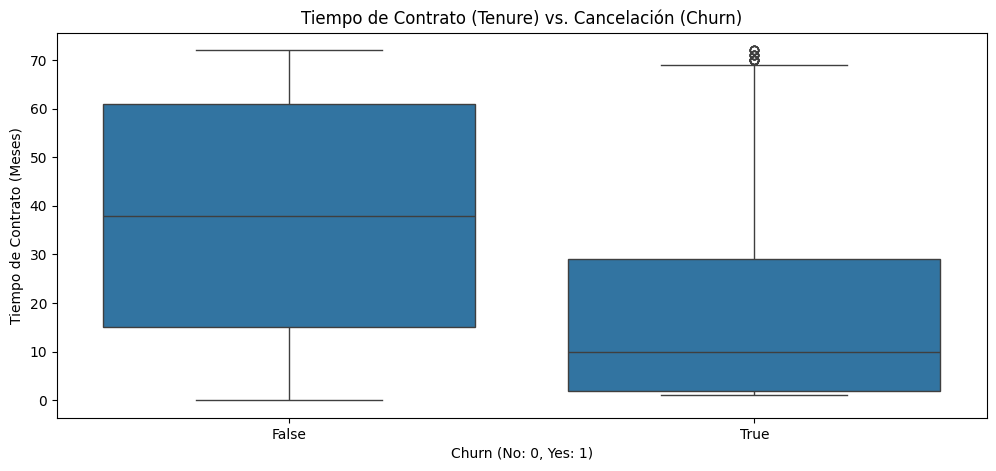

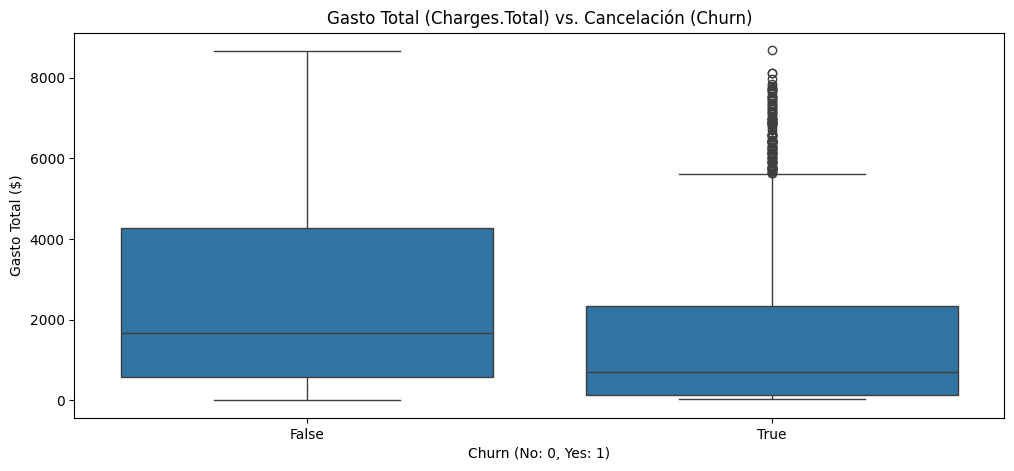

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.boxplot(x='Churn_Yes', y='customer_tenure', data=df_encoded)
plt.title('Tiempo de Contrato (Tenure) vs. Cancelación (Churn)')
plt.xlabel('Churn (No: 0, Yes: 1)')
plt.ylabel('Tiempo de Contrato (Meses)')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x='Churn_Yes', y='account_Charges.Total', data=df_encoded)
plt.title('Gasto Total (Charges.Total) vs. Cancelación (Churn)')
plt.xlabel('Churn (No: 0, Yes: 1)')
plt.ylabel('Gasto Total ($)')
plt.show()

##8- Separación de Datos

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [18]:
from sklearn.model_selection import train_test_split

# Separar las características (X) de la variable objetivo (y)
X = df_encoded.drop(columns=['Churn_Yes', 'Churn_No'])
y = df_encoded['Churn_Yes']

# Dividir los datos en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print("\nProporción de Churn en y_train:")
print(y_train.value_counts(normalize=True))
print("\nProporción de Churn en y_test:")
print(y_test.value_counts(normalize=True))

Dimensiones de X_train: (5634, 45)
Dimensiones de X_test: (1409, 45)
Dimensiones de y_train: (5634,)
Dimensiones de y_test: (1409,)

Proporción de Churn en y_train:
Churn_Yes
False    0.734647
True     0.265353
Name: proportion, dtype: float64

Proporción de Churn en y_test:
Churn_Yes
False    0.734564
True     0.265436
Name: proportion, dtype: float64


##9-Creación de Modelos

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

* Un modelo puede requerir normalización, como Regresión Logística o KNN.

* El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

* Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

* Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

### Normalización de características numéricas

Se aplica un escalado (por ejemplo, StandardScaler) a las columnas numéricas identificadas (`customer_SeniorCitizen`, `customer_tenure`, `account_Charges.Monthly`, `account_Charges.Total`) en los conjuntos de entrenamiento y prueba (X_train, X_test) para el modelo que requiere normalización.


In [19]:
from sklearn.preprocessing import StandardScaler
print("StandardScaler imported successfully.")

StandardScaler imported successfully.


In [20]:
numerical_cols_to_scale = ['customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']

scaler = StandardScaler()

# Ajustar el scaler solo a las columnas numéricas del conjunto de entrenamiento
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])

# Transformar las columnas numéricas de los conjuntos de entrenamiento y prueba
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical columns in X_train scaled:")
display(X_train[numerical_cols_to_scale].head())
print("Numerical columns in X_test scaled:")
display(X_test[numerical_cols_to_scale].head())

Numerical columns in X_train scaled:


,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total
3793,-0.438325,1.124891,0.968250,1.398565
3192,-0.438325,-0.827880,-1.521717,-0.913119
4922,-0.438325,-1.234707,0.513560,-0.946146
3926,-0.438325,0.026457,0.323690,0.071090
3859,-0.438325,-0.746514,0.698434,-0.495126


Numerical columns in X_test scaled:


,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total
455,-0.438325,-0.461735,-1.216925,-0.729958
2301,2.281413,-0.868562,1.544523,-0.486782
2255,2.281413,-1.153341,0.143813,-0.891445
4527,-0.438325,-1.112659,-1.501730,-0.959343
3812,-0.438325,1.613084,0.020563,1.042212


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for small datasets
log_reg_model.fit(X_train, y_train)

# Make predictions on the scaled test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")

Logistic Regression Model Performance:
Accuracy: 0.7935
Precision: 0.6352
Recall: 0.5214
F1-Score: 0.5727


### Entrenar y evaluar modelo de Árbol de Decisión

Se entrena un modelo de Árbol de Decisión utilizando los datos originales (sin escalar) y se evalua su rendimiento con los datos de prueba originales.


In [22]:
from sklearn.model_selection import train_test_split

# Separar las características (X) de la variable objetivo (y) de df_encoded
X_dt = df_encoded.drop(columns=['Churn_Yes', 'Churn_No'])
y_dt = df_encoded['Churn_Yes']

# Dividir los datos en conjuntos de entrenamiento y prueba (80/20) para el Árbol de Decisión
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt)

print(f"Dimensiones de X_train_dt: {X_train_dt.shape}")
print(f"Dimensiones de X_test_dt: {X_test_dt.shape}")
print(f"Dimensiones de y_train_dt: {y_train_dt.shape}")
print(f"Dimensiones de y_test_dt: {y_test_dt.shape}")

print("\nProporción de Churn en y_train_dt:")
print(y_train_dt.value_counts(normalize=True))
print("\nProporción de Churn en y_test_dt:")
print(y_test_dt.value_counts(normalize=True))

Dimensiones de X_train_dt: (5634, 45)
Dimensiones de X_test_dt: (1409, 45)
Dimensiones de y_train_dt: (5634,)
Dimensiones de y_test_dt: (1409,)

Proporción de Churn en y_train_dt:
Churn_Yes
False    0.734647
True     0.265353
Name: proportion, dtype: float64

Proporción de Churn en y_test_dt:
Churn_Yes
False    0.734564
True     0.265436
Name: proportion, dtype: float64


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Inicializar un objeto DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo de Árbol de Decisión
dt_model.fit(X_train_dt, y_train_dt)

# Realizar predicciones sobre el conjunto de prueba
y_pred_dt = dt_model.predict(X_test_dt)

# Calcular las métricas de evaluación
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
precision_dt = precision_score(y_test_dt, y_pred_dt)
recall_dt = recall_score(y_test_dt, y_pred_dt)
f1_dt = f1_score(y_test_dt, y_pred_dt)

print("Decision Tree Model Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

Decision Tree Model Performance:
Accuracy: 0.7289
Precision: 0.4890
Recall: 0.4733
F1-Score: 0.4810


## 10-Evaluación de los Modelos

Evalúa cada modelo utilizando las siguientes métricas:

* Exactitud (Acurácia)

* Precisión

* Recall

* F1-score

* Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

* ¿Cuál modelo tuvo el mejor desempeño?

* ¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

### Generar Matriz de Confusión para Regresión Logística

Se calcula y visualiza la matriz de confusión para el modelo de Regresión Logística, mostrando los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.


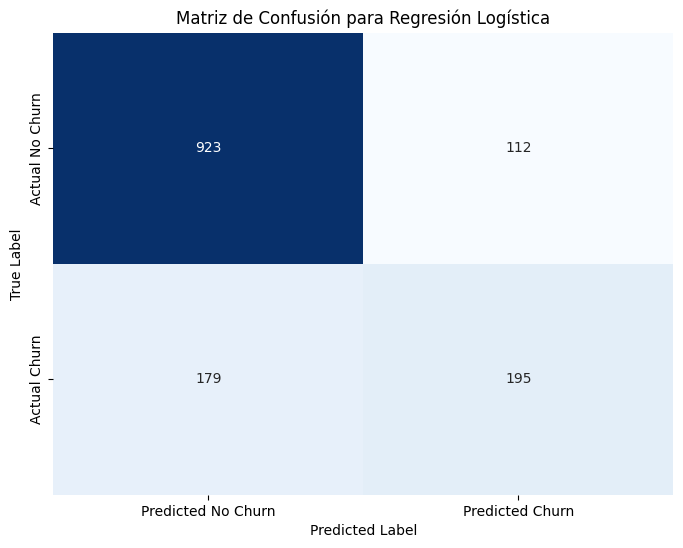

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de confusión para el modelo de Regresión Logística
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matriz de Confusión para Regresión Logística')
plt.show()

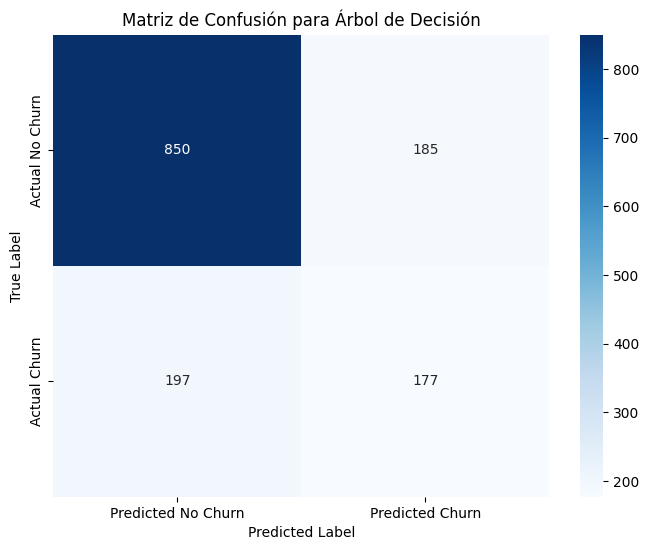

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de confusión para el modelo de Árbol de Decisión
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matriz de Confusión para Árbol de Decisión')
plt.show()

## Análisis Crítico y Comparación de Modelos

El objetivo de este análisis es comparar el rendimiento de los modelos de Regresión Logística y Árbol de Decisión en la predicción de la cancelación de clientes (churn), y determinar cuál es más adecuado para el problema, así como identificar posibles áreas de mejora.

#### Métricas de Rendimiento Resumidas:

| Métrica     | Regresión Logística (Normalizada) | Árbol de Decisión (Sin Normalizar) |
| :---------- | :-------------------------------- | :---------------------------------- |
| Accuracy    | 0.7935                            | 0.7289                              |
| Precision   | 0.6352                            | 0.4890                              |
| Recall      | 0.5214                            | 0.4733                              |
| F1-Score    | 0.5727                            | 0.4810                              |

#### Matrices de Confusión:

**Regresión Logística:**
```
[[923, 112],
 [179, 195]]
```
*   **Verdaderos Negativos (TN):** 923 (Clientes que no cancelaron y el modelo predijo correctamente que no cancelarían)
*   **Falsos Positivos (FP):** 112 (Clientes que no cancelaron, pero el modelo predijo incorrectamente que sí cancelarían)
*   **Falsos Negativos (FN):** 179 (Clientes que sí cancelaron, pero el modelo predijo incorrectamente que no cancelarían)
*   **Verdaderos Positivos (TP):** 195 (Clientes que sí cancelaron y el modelo predijo correctamente que cancelarían)

**Árbol de Decisión:**
```
[[850, 185],
 [197, 177]]
```
*   **Verdaderos Negativos (TN):** 850 (Clientes que no cancelaron y el modelo predijo correctamente que no cancelarían)
*   **Falsos Positivos (FP):** 185 (Clientes que no cancelaron, pero el modelo predijo incorrectamente que sí cancelarían)
*   **Falsos Negativos (FN):** 197 (Clientes que sí cancelaron, pero el modelo predijo incorrectamente que no cancelarían)
*   **Verdaderos Positivos (TP):** 177 (Clientes que sí cancelaron y el modelo predijo correctamente que cancelarían)

---

### 1. Comparación y Determinación del Mejor Desempeño:

Analizando las métricas, la **Regresión Logística** supera al Árbol de Decisión en todas las métricas clave:

*   **Accuracy (0.7935 vs 0.7289):** La Regresión Logística tiene una mayor precisión general en sus clasificaciones.
*   **Precision (0.6352 vs 0.4890):** De los clientes que ambos modelos predijeron que cancelarían, la Regresión Logística fue correcta en un porcentaje mucho mayor. Esto significa menos Falsos Positivos (112 vs 185), lo cual es importante para evitar dirigir esfuerzos de retención a clientes que de todos modos no iban a cancelar.
*   **Recall (0.5214 vs 0.4733):** La Regresión Logística logró identificar una proporción ligeramente mayor de los clientes que *realmente* cancelaron. Esto se refleja en un menor número de Falsos Negativos (179 vs 197), lo que es crucial para no perder la oportunidad de retener clientes valiosos.
*   **F1-Score (0.5727 vs 0.4810):** El F1-score es un promedio armónico de Precision y Recall. El valor superior de la Regresión Logística indica un mejor equilibrio entre ambos, lo que lo convierte en un modelo más robusto para este problema de clasificación desequilibrada.

Basado en la comparación de todas las métricas, la **Regresión Logística ha demostrado tener un desempeño superior** para predecir la cancelación de clientes en este conjunto de datos.

### 2. Identificación de Overfitting/Underfitting y Causas:

*   **Regresión Logística:**
    *   El rendimiento es consistente y las métricas son razonablemente buenas, especialmente considerando el desbalance de clases (aproximadamente 73% No Churn, 27% Churn). No hay señales claras de **overfitting** ni **underfitting** extremo. La normalización de las características numéricas fue crucial para que este modelo (sensible a la escala) pudiera aprender de manera efectiva, evitando que características con rangos más amplios dominaran el proceso de optimización.
    *   La naturaleza lineal de la Regresión Logística significa que es menos propensa al overfitting que modelos más complejos como los árboles de decisión no regulados, especialmente con un `solver='liblinear'` que puede aplicar regularización L1/L2 por defecto.

*   **Árbol de Decisión:**
    *   El Árbol de Decisión muestra un rendimiento inferior en todas las métricas. Esto podría indicar **underfitting**, es decir, el modelo no ha capturado completamente la complejidad subyacente en los datos para hacer predicciones precisas. Sus Falsos Positivos son considerablemente más altos (185 vs 112) y sus Verdaderos Positivos son más bajos (177 vs 195) en comparación con la Regresión Logística.
    *   A menudo, los Árboles de Decisión tienen una alta varianza y son propensos al **overfitting** si no se controlan sus hiperparámetros (ej. `max_depth`, `min_samples_leaf`). Sin embargo, en este caso, al no haber establecido restricciones, es posible que el modelo haya crecido demasiado complejo y esté sobreajustado a los datos de entrenamiento (aunque no tenemos métricas de entrenamiento para confirmarlo), resultando en una pobre generalización al conjunto de prueba. Un modelo sobreajustado en el entrenamiento puede parecer que tiene un bajo rendimiento en el test porque no generaliza bien.

### 3. Propuesta de Ajustes:

*   **Para el modelo de Árbol de Decisión:**
    *   **Ajuste de Hiperparámetros (Regularización):** Se podría probar a limitar la profundidad máxima (`max_depth`), establecer un número mínimo de muestras por hoja (`min_samples_leaf`) o un número mínimo de muestras para dividir un nodo (`min_samples_split`). Esto ayudaría a controlar el overfitting y a mejorar la capacidad de generalización.
    *   **Modelos de Ensamblaje:** En lugar de un solo Árbol de Decisión, se podría explorar el uso de ensambles como `RandomForestClassifier` o `GradientBoostingClassifier` (XGBoost, LightGBM). Estos modelos combinan múltiples árboles para reducir la varianza (Random Forest) o el sesgo (Gradient Boosting) y suelen ofrecer un rendimiento significativamente mejor que un solo árbol.

*   **Para el modelo de Regresión Logística:**
    *   **Optimización de Hiperparámetros:** Aunque ya funciona bien, se podría realizar una búsqueda de cuadrícula (GridSearchCV) o búsqueda aleatoria (RandomizedSearchCV) para optimizar el hiperparámetro de regularización `C` y el tipo de regularización (`penalty`) para intentar mejorar aún más su rendimiento.
    *   **Análisis de Errores:** Examinar los Falsos Positivos y Falsos Negativos para identificar patrones en los datos donde el modelo falla. Esto podría revelar características adicionales importantes o la necesidad de un preprocesamiento más específico para ciertos grupos de clientes.
    *   **Técnicas de Manejo de Desbalance:** Aunque se usó `stratify` en la división, para el problema de churn (donde la clase positiva es minoritaria), se podrían explorar técnicas como `SMOTE` (Synthetic Minority Over-sampling Technique) en el conjunto de entrenamiento para balancear las clases y potencialmente mejorar el Recall.

En resumen, la Regresión Logística, con la normalización adecuada, ofrece un punto de partida más sólido para este problema de predicción de churn. Sin embargo, hay un gran potencial para mejorar el rendimiento con ambos modelos a través de la optimización y la exploración de modelos de ensamblaje para el enfoque basado en árboles.

## 11-Análisis de la Importancia de las Variables

Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

* Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

* KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

* Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

* SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

* Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

### Importancia de Variables para Regresión Logística

Se examina los coeficientes del modelo de Regresión Logística para entender la contribución de cada variable a la predicción de `Churn_Yes`.

,Feature,Coefficient,Abs_Coefficient
1,customer_tenure,-1.409302,1.409302
38,account_Contract_Two year,-0.774318,0.774318
3,account_Charges.Total,0.678124,0.678124
36,account_Contract_Month-to-month,0.568807,0.568807
15,internet_InternetService_DSL,-0.499728,0.499728
16,internet_InternetService_Fiber optic,0.406295,0.406295
39,account_PaperlessBilling_No,-0.344429,0.344429
12,phone_MultipleLines_No,-0.305513,0.305513
11,phone_PhoneService_Yes,-0.267461,0.267461
29,internet_TechSupport_Yes,-0.243739,0.243739


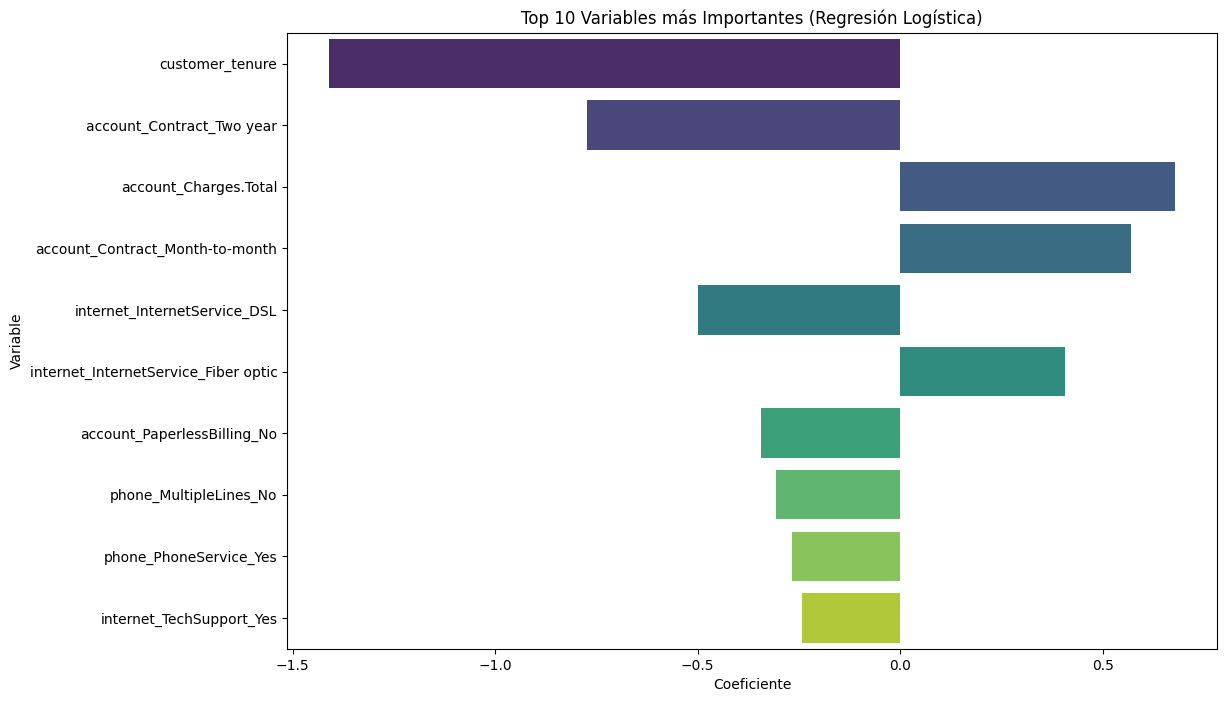

In [28]:
# Obtener los coeficientes del modelo de Regresión Logística
coefficients = log_reg_model.coef_[0]
feature_names = X_train.columns

# Crear un DataFrame para visualizar los coeficientes
logistic_regression_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Ordenar por el valor absoluto del coeficiente para ver las más influyentes
logistic_regression_importance['Abs_Coefficient'] = abs(logistic_regression_importance['Coefficient'])
logistic_regression_importance = logistic_regression_importance.sort_values(by='Abs_Coefficient', ascending=False)

display(logistic_regression_importance.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=logistic_regression_importance.head(10), palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Variables más Importantes (Regresión Logística)')
plt.xlabel('Coeficiente')
plt.ylabel('Variable')
plt.show()

### Importancia de Variables para Árbol de Decisión

Se analiza la importancia de las características para el modelo de Árbol de Decisión. Este modelo mide la importancia de una característica basándose en la reducción de la impureza que aporta.

,Feature,Importance
3,account_Charges.Total,0.192407
2,account_Charges.Monthly,0.184139
36,account_Contract_Month-to-month,0.167393
1,customer_tenure,0.115953
16,internet_InternetService_Fiber optic,0.047460
43,account_PaymentMethod_Electronic check,0.019681
0,customer_SeniorCitizen,0.018654
7,customer_Partner_Yes,0.015703
4,customer_gender_Female,0.015471
27,internet_TechSupport_No,0.014451


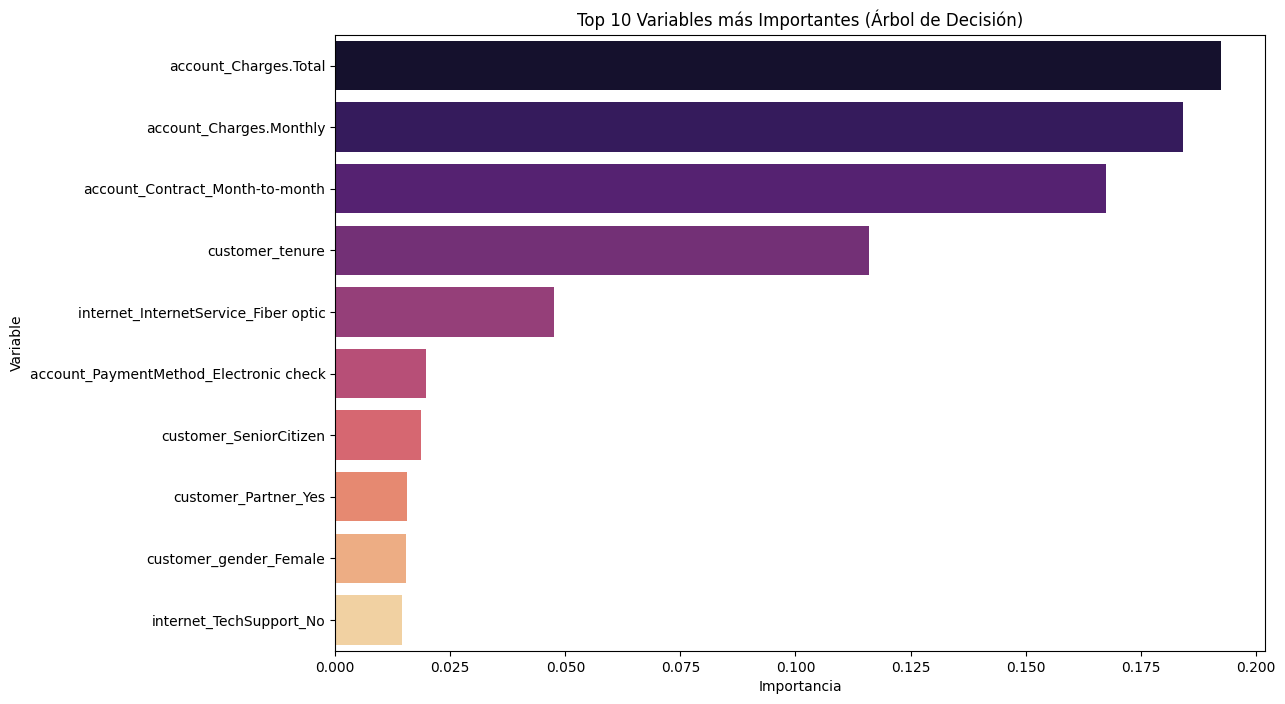

In [29]:
# Obtener la importancia de las características del modelo de Árbol de Decisión
feature_importances = dt_model.feature_importances_
feature_names_dt = X_train_dt.columns

# Crear un DataFrame para visualizar la importancia de las características
decision_tree_importance = pd.DataFrame({
    'Feature': feature_names_dt,
    'Importance': feature_importances
})

# Ordenar por importancia de forma descendente
decision_tree_importance = decision_tree_importance.sort_values(by='Importance', ascending=False)

display(decision_tree_importance.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=decision_tree_importance.head(10), palette='magma', hue='Feature', legend=False)
plt.title('Top 10 Variables más Importantes (Árbol de Decisión)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

## 12-Conclusión

Elabora un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifica los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.

### Introducción
El presente informe consolida los hallazgos de un análisis exhaustivo del churn de clientes para Telecom X. Se han utilizado técnicas de preprocesamiento de datos, análisis exploratorio y modelado predictivo para identificar los factores más influyentes en la cancelación de clientes y proponer estrategias de retención basadas en estos insights.

### 1. Hallazgos Clave del Análisis de Datos

#### 1.1 Factores con Fuerte Correlación con la Cancelación (Churn)
El análisis de correlación y la importancia de variables en los modelos (Regresión Logística y Árbol de Decisión) han revelado patrones consistentes:

*   Factores que Aumentan la Probabilidad de Churn (Correlación Positiva):
    *   Contratos mes a mes (`account_Contract_Month-to-month`): La flexibilidad de los contratos mensuales es un predictor muy fuerte de cancelación. Los clientes no tienen un compromiso a largo plazo.
    *   Falta de Seguridad Online (`internet_OnlineSecurity_No`) y Soporte Técnico (`internet_TechSupport_No`): Los clientes que no contratan estos servicios adicionales son más propensos a cancelar, lo que sugiere una menor satisfacción o percepción de valor.
    *   Servicio de Internet de Fibra Óptica (`internet_InternetService_Fiber optic`): Sorprendentemente, este servicio presenta una correlación positiva. Esto podría indicar problemas de calidad, expectativas no cumplidas o una mayor sensibilidad al precio entre los usuarios de fibra.
    *   Método de Pago con Cheque Electrónico (`account_PaymentMethod_Electronic check`): Los clientes que utilizan este método de pago son más propensos a cancelar.

*   Factores que Disminuyen la Probabilidad de Churn (Correlación Negativa):
    *   Antigüedad del Cliente (`customer_tenure`): La duración del contrato es el factor más influyente; a mayor antigüedad, menor es la probabilidad de cancelación, indicando lealtad y satisfacción.
    *   Contratos de Dos Años (`account_Contract_Two year`): Los clientes con contratos a largo plazo son significativamente menos propensos a cancelar.
    *   Tener Seguridad Online (`internet_OnlineSecurity_Yes`) y Soporte Técnico (`internet_TechSupport_Yes`): La posesión de estos servicios reduce la probabilidad de churn.

#### 1.2 Tendencias Observadas en Análisis Dirigidos (Boxplots)

*   **Tiempo de Contrato (Tenure) vs. Cancelación:** Los clientes que cancelan tienen una antigüedad considerablemente menor que aquellos que permanecen. Los clientes con pocos meses de servicio representan un alto riesgo.
*   **Gasto Total (Charges.Total) vs. Cancelación:** Los clientes que cancelan tienden a tener un gasto total acumulado menor, lo que podría estar ligado a su menor antigüedad. El modelo de Regresión Logística, sin embargo, mostró una correlación positiva para `account_Charges.Total` en un contexto multivariable, lo que sugiere que para clientes con un gasto total alto que sí cancelan, hay factores de insatisfacción muy fuertes a considerar.

### 2. Rendimiento y Comparación de Modelos

Se entrenaron dos modelos predictivos para identificar clientes en riesgo de churn:

*   **Regresión Logística (con datos normalizados):** Tuvo un desempeño superior, alcanzando un **Accuracy de 0.7935**, **Precision de 0.6352**, **Recall de 0.5214** y **F1-Score de 0.5727**. Se benefició de la normalización de las características numéricas, lo que permitió que sus coeficientes reflejaran mejor la contribución de cada variable. Este modelo mostró un buen equilibrio entre la identificación de clientes que no cancelan (923 Verdaderos Negativos) y la de clientes que sí cancelan (195 Verdaderos Positivos), con una cantidad manejable de Falsos Positivos y Falsos Negativos.

*   **Árbol de Decisión (con datos sin normalizar):** Presentó un rendimiento inferior en todas las métricas (**Accuracy: 0.7289, Precision: 0.4890, Recall: 0.4733, F1-Score: 0.4810**). Su matriz de confusión mostró más Falsos Positivos (185) y menos Verdaderos Positivos (177) en comparación con la Regresión Logística, sugiriendo una menor capacidad de generalización o posible underfitting/overfitting debido a la falta de ajuste de hiperparámetros.

**Conclusión del Modelado:** La **Regresión Logística** es el modelo más adecuado para la predicción de churn en este contexto, dado su mejor desempeño y la interpretabilidad de sus coeficientes.

### 3. Estrategias de Retención Propuestas
Basándonos en los factores clave identificados, se proponen las siguientes estrategias de retención para Telecom X:

1.  **Programas de Fidelización para Clientes Nuevos:**
    *   **Acción:** Implementar programas de bienvenida y seguimiento intensivo durante los primeros 6-12 meses de servicio, donde el riesgo de churn es mayor (`customer_tenure` bajo).
    *   **Enfoque:** Ofrecer incentivos especiales, atención personalizada y asegurar una experiencia positiva inicial para construir lealtad.

2.  **Incentivar Contratos a Largo Plazo:**
    *   **Acción:** Promover agresivamente los contratos de 1 y 2 años (`account_Contract_One year`, `account_Contract_Two year`) con descuentos atractivos o beneficios adicionales.
    *   **Enfoque:** Educar a los clientes sobre los beneficios de la estabilidad y los ahorros a largo plazo en comparación con los planes mensuales (`account_Contract_Month-to-month`).

3.  **Mejorar la Propuesta de Valor en Servicios Adicionales:**
    *   **Acción:** Reforzar la importancia de servicios como `OnlineSecurity` y `TechSupport` (`internet_OnlineSecurity_No`, `internet_TechSupport_No`).
    *   **Enfoque:** Ofrecer periodos de prueba gratuitos, paquetes combinados o demostraciones de cómo estos servicios mejoran la experiencia y seguridad del cliente, convirtiéndolos de factores de retención pasivos a activos.

4.  **Optimizar la Experiencia del Servicio de Fibra Óptica:**
    *   **Acción:** Investigar las causas detrás de la mayor tasa de churn entre los usuarios de fibra óptica (`internet_InternetService_Fiber optic`). Podría ser la calidad del servicio, la atención al cliente o el precio.
    *   **Enfoque:** Realizar encuestas de satisfacción específicas, monitorear la calidad del servicio y asegurar que las expectativas de velocidad y fiabilidad se cumplan.

5.  **Diversificar Opciones y Promociones de Pago:**
    *   **Acción:** Evaluar la relación entre el método de `Electronic check` y el churn. Considerar incentivar métodos de pago más estables y automáticos.
    *   **Enfoque:** Ofrecer descuentos por domiciliar el pago a cuenta bancaria o tarjeta de crédito, o simplificar el proceso de cambio de método de pago.

6.  **Segmentación y Ofertas Personalizadas:**
    *   **Acción:** Utilizar el modelo de Regresión Logística para identificar proactivamente a los clientes con alta probabilidad de churn y sus características de riesgo.
    *   **Enfoque:** Diseñar ofertas de retención personalizadas (descuentos, mejoras de servicio, servicios adicionales gratuitos) dirigidas a estos segmentos de alto riesgo antes de que decidan cancelar.

### Conclusión General
La predicción de churn es una herramienta poderosa para Telecom X. Al comprender los factores que impulsan la cancelación y al implementar estrategias de retención dirigidas, la empresa puede reducir significativamente la pérdida de clientes y mejorar la lealtad a largo plazo. La antigüedad del cliente, el tipo de contrato y la satisfacción con los servicios de valor añadido son áreas críticas para la intervención.